## 1 — Introduction

# 03 — Comparaison MALT vs BERTopic intra-macro vs KMeans intra-macro

**MALT** produit des motifs latents \(z\) sur la cible après adaptation.

**BERTopic intra-macro via p0** : transfert source → projecteur → ancres → **\(p_0(y|x)\)** sur la cible ; pseudo-macro dure par argmax (`p0_macro_name`) ; **BERTopic** séparé par macro (sans adaptation MALT).

**KMeans intra-macro + c-TF-IDF** : même découpage macro que BERTopic ; KMeans + c-TF-IDF.

**Métriques principales** : C_v, NPMI, Topic Diversity, Redundancy, Coverage. Section **macro** : distributions \(p_0\), \(p_t\), transition \(p_0 \rightarrow p_t\).


## 2 — Imports et paramètres


In [11]:
# --- Paramètres (Papermill / exécution manuelle) ---
# Chemins relatifs ci-dessous : racine = dossier du dépôt (parent de topic_eval/), pas notebooks/.
MALT_EXPORTS_DIR = "runs/malt_btp_to_mettalurgie_qwen06/exports"
MALT_EVAL_DIR = "runs/malt_btp_to_mettalurgie_qwen06/evaluation"
OUTPUT_DIR = "outputs/topic_comparison"
TEXT_COL = "sentence"
MACRO_P0_COL = "p0_macro_name"
MACRO_PT_COL = "pt_macro_name"
Z_COL = "z_hat"
N_TOP_WORDS = 10
N_REPRESENTATIVE_SENTENCES = 8
N_BERTOPIC_TOPICS_PER_MACRO = "auto"
N_KMEANS_CLUSTERS_PER_MACRO = 8
RANDOM_STATE = 42
MIN_TOPIC_SIZE = 15
MAX_DOCS_FOR_BERTOPIC = None
USE_PROJECTED_SOURCE_EMBEDDINGS = True
USE_PROJECTED_ADAPTED_EMBEDDINGS_FOR_MALT = True


In [12]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np

if int(np.__version__.split(".", 1)[0]) >= 2:
    _py = sys.executable
    raise ImportError(
        "NumPy 2.x est chargé alors que le matplotlib de cet environnement (Anaconda) "
        "est souvent compilé pour NumPy 1.x → conflit à l’import de matplotlib.\n\n"
        f"Interpréteur du noyau : {_py}\n\n"
        "Corrigez puis Kernel → Restart, par exemple :\n\n"
        f'  "{_py}" -m pip install "numpy<2" --force-reinstall\n\n'
        "ou :\n\n"
        '  conda install "numpy<2" "matplotlib" "scipy" -y\n\n'
        "Réinstallez aussi les deps du dépôt : pip install -r requirements.txt"
    )

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

from IPython.display import display

def _find_repo_root() -> Path:
    # Racine du pipeline texte (cwd peut être notebooks/ ou racine SAFER).
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "topic_eval" / "__init__.py").is_file():
            return candidate
        if (candidate / "text" / "topic_eval" / "__init__.py").is_file():
            return candidate / "text"
    return here


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("PYTHONPATH racine :", REPO_ROOT)

from topic_eval.bertopic_baseline import run_bertopic_intra_macro
from topic_eval.compare_topics import (
    build_malt_topics_df,
    build_topics_by_macro_qualitative,
    check_malt_export_files,
    load_embeddings_and_metadata,
    write_topic_comparison_report_md,
)
from topic_eval.paths import resolve_repo_path
from topic_eval.kmeans_ctfidf_baseline import run_kmeans_ctfidf_intra_macro
from topic_eval.metrics_topic_quality import (
    build_metrics_both_filters,
    macro_level_metrics,
)
from topic_eval.topic_cleaning import load_domain_stopwords
from topic_eval.visualization import save_all_comparison_figures

sns.set_theme(style="whitegrid")


PYTHONPATH racine : C:\Users\aho\Documents\analysis factor project\SCGM\SCGM


## 3 — Chargement des données et contrôle d’alignement


In [13]:
exports_path = resolve_repo_path(MALT_EXPORTS_DIR, REPO_ROOT)
OUTPUT_DIR = str(resolve_repo_path(OUTPUT_DIR, REPO_ROOT))
check_malt_export_files(exports_path)

meta, emb_source, emb_adapted, extras = load_embeddings_and_metadata(exports_path, TEXT_COL)
p0_arr = extras["p0"]
pz_arr = extras["pz"]
prob_y_z = extras["prob_y_z"]
nu_arr = extras["nu"]

if TEXT_COL not in meta.columns:
    raise KeyError(f"Colonne texte absente : {TEXT_COL}")

text_series = meta[TEXT_COL].astype(str)
valid_mask = text_series.notna() & (text_series.str.strip() != "") & (text_series.str.lower() != "nan")
idx = np.flatnonzero(valid_mask.to_numpy())
meta = meta.iloc[idx].reset_index(drop=True)
emb_source = np.asarray(emb_source)[idx]
emb_adapted = np.asarray(emb_adapted)[idx]
extras["p0"] = p0_arr = p0_arr[idx]
extras["pt"] = extras["pt"][idx]
extras["pz"] = pz_arr = pz_arr[idx]

if MAX_DOCS_FOR_BERTOPIC is not None and int(MAX_DOCS_FOR_BERTOPIC) > 0:
    n_cap = int(MAX_DOCS_FOR_BERTOPIC)
    meta = meta.iloc[:n_cap].reset_index(drop=True)
    sl = slice(None, n_cap)
    emb_source = emb_source[sl]
    emb_adapted = emb_adapted[sl]
    p0_arr = p0_arr[sl]
    pz_arr = pz_arr[sl]
    extras["pt"] = extras["pt"][sl]

docs = meta[TEXT_COL].astype(str).tolist()
n_valid = len(meta)
print("Documents avec texte valide :", n_valid)

STOPWORDS_PATH = Path(OUTPUT_DIR) / "stopwords_domain.txt"
stopwords_domain = load_domain_stopwords(STOPWORDS_PATH)

tables_dir = Path(OUTPUT_DIR) / "tables"
fig_dir = Path(OUTPUT_DIR) / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

display(meta[MACRO_P0_COL].value_counts().rename("p0_macro_name"))
display(meta[MACRO_PT_COL].value_counts().rename("pt_macro_name"))
vc_z = meta[Z_COL].value_counts()
print("Nombre de z actifs :", int(vc_z.shape[0]))
display(vc_z.head(20))


Documents avec texte valide : 22487


p0_macro_name
A0    13758
C      6051
A1     1846
B       832
Name: p0_macro_name, dtype: int64

pt_macro_name
A0    13778
C      6201
A1     1670
B       838
Name: pt_macro_name, dtype: int64

Nombre de z actifs : 18


z_hat
24    11064
1      4891
26     1202
3      1027
22      594
23      529
27      511
10      499
5       481
31      471
17      408
25      276
29      180
18      161
6       121
11       31
28       25
7        16
Name: count, dtype: int64

### Graphiques exploratoires (distributions macro et z)


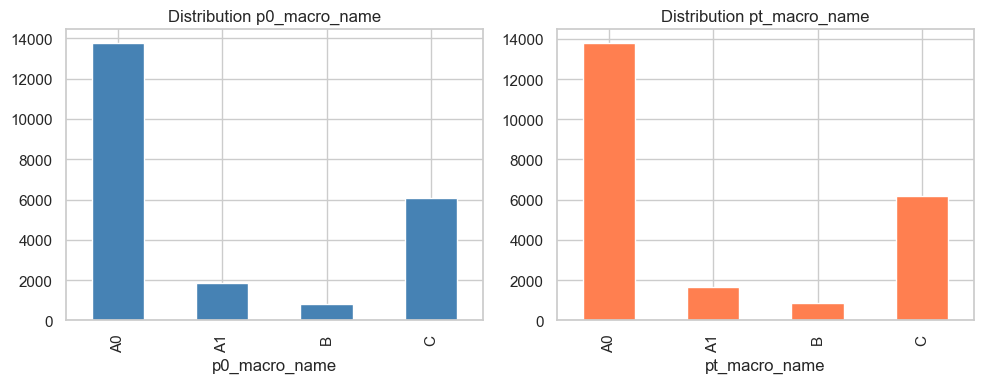

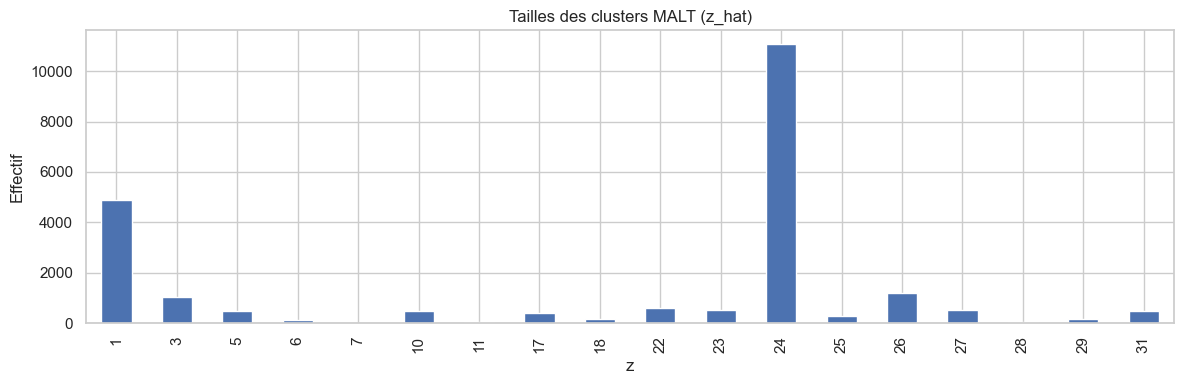

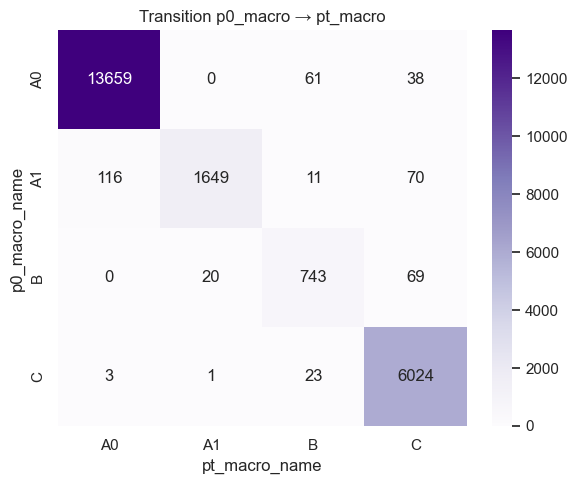

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
meta[MACRO_P0_COL].value_counts().reindex(["A0", "A1", "B", "C"]).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribution p0_macro_name")
meta[MACRO_PT_COL].value_counts().reindex(["A0", "A1", "B", "C"]).plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Distribution pt_macro_name")
plt.tight_layout()
plt.savefig(fig_dir / "distributions_p0_pt.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 4))
meta[Z_COL].value_counts().sort_index().plot(kind="bar")
plt.title("Tailles des clusters MALT (z_hat)")
plt.xlabel("z")
plt.ylabel("Effectif")
plt.tight_layout()
plt.savefig(fig_dir / "z_cluster_sizes.png", dpi=150)
plt.show()

ct = pd.crosstab(meta[MACRO_P0_COL], meta[MACRO_PT_COL])
plt.figure(figsize=(6, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Purples")
plt.title("Transition p0_macro → pt_macro")
plt.xlabel("pt_macro_name")
plt.ylabel("p0_macro_name")
plt.tight_layout()
plt.savefig(fig_dir / "heatmap_p0_to_pt.png", dpi=150)
plt.show()


## 4 — Nettoyage des top words

Implémenté dans `topic_eval/topic_cleaning.py` : `load_domain_stopwords`, `normalize_token`, `clean_top_words`, `preprocess_for_ctfidf` (minuscules, ponctuation, tokens courts, chiffres, stopwords FR + fichier métier).


## 5 — Topics MALT (z_hat) + c-TF-IDF


In [15]:
emb_malt = emb_adapted if USE_PROJECTED_ADAPTED_EMBEDDINGS_FOR_MALT else emb_source

malt_topics_df = build_malt_topics_df(
    meta=meta,
    docs=docs,
    projected_adapted=emb_malt,
    pz=pz_arr,
    prob_y_z=prob_y_z,
    nu=nu_arr,
    stopwords_domain=stopwords_domain,
    text_col=TEXT_COL,
    n_top_words=N_TOP_WORDS,
    n_representative_sentences=N_REPRESENTATIVE_SENTENCES,
    z_col=Z_COL,
)
malt_topics_df.to_csv(tables_dir / "malt_topics.csv", index=False)
display(malt_topics_df.head(12))


,method,topic_id,macro,n_docs,coverage_docs,top_words,top_sentences,mean_confidence,source
0,MALT adapted + c-TF-IDF,1,C,4891,0.217503,,"La victime est décédée sur le coup, d'un traum...",0.977839,MALT adapted
1,MALT adapted + c-TF-IDF,3,A1,1027,0.045671,,A noter la vérification partielle de l'install...,0.968064,MALT adapted
2,MALT adapted + c-TF-IDF,5,A0,481,0.021390,,Il s'aperçoit qu'une gouttière est remplie de ...,0.897905,MALT adapted
3,MALT adapted + c-TF-IDF,6,A1,121,0.005381,,Le collègue aurait pu confondre les manettes v...,0.901613,MALT adapted
4,MALT adapted + c-TF-IDF,7,A0,16,0.000712,,La victime avait reçu une formation par le che...,0.926230,MALT adapted
5,MALT adapted + c-TF-IDF,10,A1,499,0.022191,,- Les opérations de réglages/mise au point de ...,0.938089,MALT adapted
6,MALT adapted + c-TF-IDF,11,C,31,0.001379,câble,Le contact entre le câble et lappareil est pr...,0.917421,MALT adapted
7,MALT adapted + c-TF-IDF,17,B,408,0.018144,,Alors qu'il arrivait à une intersection de rou...,0.928445,MALT adapted
8,MALT adapted + c-TF-IDF,18,B,161,0.007160,,"De façon incompréhensible, un ballot reste coi...",0.905601,MALT adapted
9,MALT adapted + c-TF-IDF,22,C,594,0.026415,,Arrivée à 400 m de l'endroit où elle devait to...,0.912812,MALT adapted


## 6 — Baseline BERTopic intra-macro (p0 uniquement)


In [16]:
emb_baseline = emb_source if USE_PROJECTED_SOURCE_EMBEDDINGS else emb_adapted

bertopic_topics_df = run_bertopic_intra_macro(
    docs=docs,
    embeddings=emb_baseline,
    macro_labels=meta[MACRO_P0_COL].tolist(),
    stopwords_domain=stopwords_domain,
    min_topic_size=MIN_TOPIC_SIZE,
    random_state=RANDOM_STATE,
    n_top_words=N_TOP_WORDS,
    n_representative_sentences=N_REPRESENTATIVE_SENTENCES,
)
bertopic_topics_df.to_csv(tables_dir / "bertopic_intra_macro_topics.csv", index=False)
display(bertopic_topics_df.head(12))


,method,topic_id,macro,n_docs,coverage_docs,top_words,top_sentences,mean_confidence,source
0,BERTopic intra-macro via p0,A0_-1,A0,5727,0.254680,,"Un responsable bureau détude et marketing, âg...",0.000000,BERTopic intra-macro via p0
1,BERTopic intra-macro via p0,A0_0,A0,111,0.004936,pompiers secours samu secouristes intervenus s...,Les pompiers rejoignent les SST et prennent en...,0.425587,BERTopic intra-macro via p0
2,BERTopic intra-macro via p0,A0_1,A0,107,0.004758,pesant poids tonnes tonne pse estim kilos environ,La hauteur de la charge est d'environ 360 mm p...,0.094837,BERTopic intra-macro via p0
3,BERTopic intra-macro via p0,A0_2,A0,107,0.004758,jour laccident daccident repris seule dclarati...,C'est le travail qu'il effectuait le jour de l...,0.418944,BERTopic intra-macro via p0
4,BERTopic intra-macro via p0,A0_3,A0,81,0.003602,tlphon lentreprise jalousie tlphonique collgue...,"Le lendemain, deux lettres seront retrouvées d...",0.312224,BERTopic intra-macro via p0
5,BERTopic intra-macro via p0,A0_4,A0,66,0.002935,mcanicien changer pneumatique ans augets lentr...,"La victime, technicien de maintenance à l'entr...",0.273104,BERTopic intra-macro via p0
6,BERTopic intra-macro via p0,A0_5,A0,63,0.002802,hauteur plancher mtallique fauxplafond bois co...,Ce matériel comprend : un convoyeur central fi...,0.240876,BERTopic intra-macro via p0
7,BERTopic intra-macro via p0,A0_6,A0,56,0.002490,inhabituelle navait dhoraires forfait priori e...,Néanmoins il apparaît des éléments de contexte...,0.265366,BERTopic intra-macro via p0
8,BERTopic intra-macro via p0,A0_7,A0,49,0.002179,planchers llingue extrmit projetes aligns alen...,Elles sont fermées d'un côté par un fond vissé...,0.403314,BERTopic intra-macro via p0
9,BERTopic intra-macro via p0,A0_8,A0,48,0.002135,mode modes bimanuelle pdale automatique slecte...,"Le mode réglage est resté actif, celui-ci shun...",0.162909,BERTopic intra-macro via p0


## 7 — Baseline KMeans intra-macro + c-TF-IDF


In [17]:
kmeans_topics_df = run_kmeans_ctfidf_intra_macro(
    docs=docs,
    embeddings=emb_baseline,
    macro_labels=meta[MACRO_P0_COL].tolist(),
    n_clusters_per_macro=N_KMEANS_CLUSTERS_PER_MACRO,
    stopwords_domain=stopwords_domain,
    random_state=RANDOM_STATE,
    n_top_words=N_TOP_WORDS,
    n_representative_sentences=N_REPRESENTATIVE_SENTENCES,
)
kmeans_topics_df.to_csv(tables_dir / "kmeans_intra_macro_topics.csv", index=False)
display(kmeans_topics_df.head(12))


,method,topic_id,macro,n_docs,coverage_docs,top_words,top_sentences,mean_confidence,source
0,KMeans intra-macro + c-TF-IDF,A0_km_0,A0,2360,0.104950,,Il arrive vers 15 h 30 chez le client afin d'a...,0.628758,KMeans intra-macro + c-TF-IDF
1,KMeans intra-macro + c-TF-IDF,A0_km_1,A0,1294,0.057544,,Le mécanicien a amené auprès du véhicule un fû...,0.588341,KMeans intra-macro + c-TF-IDF
2,KMeans intra-macro + c-TF-IDF,A0_km_2,A0,1737,0.077245,,Il doit préparer quatre pièces de bridage en a...,0.586150,KMeans intra-macro + c-TF-IDF
3,KMeans intra-macro + c-TF-IDF,A0_km_3,A0,1379,0.061324,,La victime - un ébavureur de 25 ans - procédai...,0.570952,KMeans intra-macro + c-TF-IDF
4,KMeans intra-macro + c-TF-IDF,A0_km_4,A0,1561,0.069418,,L'opérateur situé au pupitre a regardé les par...,0.584223,KMeans intra-macro + c-TF-IDF
5,KMeans intra-macro + c-TF-IDF,A0_km_5,A0,2355,0.104727,ans,"La victime, 53 ans, est mécanicien de maintena...",0.654452,KMeans intra-macro + c-TF-IDF
6,KMeans intra-macro + c-TF-IDF,A0_km_6,A0,1959,0.087117,,Cette activité est effectuée en moyenne une à ...,0.626612,KMeans intra-macro + c-TF-IDF
7,KMeans intra-macro + c-TF-IDF,A0_km_7,A0,1113,0.049495,,"Revenu près du véhicule, il s'allonge au sol p...",0.592339,KMeans intra-macro + c-TF-IDF
8,KMeans intra-macro + c-TF-IDF,A1_km_0,A1,221,0.009828,,La préparation probablement insuffisante du tr...,0.575064,KMeans intra-macro + c-TF-IDF
9,KMeans intra-macro + c-TF-IDF,A1_km_1,A1,229,0.010184,,Le chalumeau était ancien et sans clapets inté...,0.602884,KMeans intra-macro + c-TF-IDF


## 8–9 — Métriques et tableau comparatif


In [18]:
methods = [
    ("MALT adapted + c-TF-IDF", malt_topics_df),
    ("BERTopic intra-macro via p0", bertopic_topics_df),
    ("KMeans intra-macro + c-TF-IDF", kmeans_topics_df),
]

rows_main = []
rows_raw = []
for label, tdf in methods:
    m, r = build_metrics_both_filters(tdf, docs, label, stopwords_domain, N_TOP_WORDS, MIN_TOPIC_SIZE)
    rows_main.append(m.iloc[0].to_dict())
    rows_raw.append(r.iloc[0].to_dict())

metrics_filtered = pd.DataFrame(rows_main)
metrics_unfiltered = pd.DataFrame(rows_raw)
print("=== Métriques (topics avec n_docs >= MIN_TOPIC_SIZE) ===")
display(metrics_filtered.round(3))

comparison_metrics_df = metrics_filtered[
    [
        "method",
        "n_topics",
        "coverage",
        "cv",
        "npmi",
        "topic_diversity",
        "redundancy",
        "mean_topic_size",
        "median_topic_size",
    ]
].copy()
comparison_metrics_df.to_csv(tables_dir / "topic_quality_comparison.csv", index=False)
comparison_metrics_df.to_latex(tables_dir / "topic_quality_comparison.tex", index=False, float_format="%.3f")
metrics_unfiltered.to_csv(tables_dir / "topic_quality_comparison_unfiltered.csv", index=False)


=== Métriques (topics avec n_docs >= MIN_TOPIC_SIZE) ===


,method,n_topics,n_valid_topics,coverage,cv,npmi,topic_diversity,redundancy,mean_pairwise_jaccard,mean_topic_size,median_topic_size,min_topic_filter_applied
0,MALT adapted + c-TF-IDF,18,18,1.000,NaN,NaN,0.017,0.983,0.000,1249.278,476.0,True
1,BERTopic intra-macro via p0,872,302,0.654,0.338,-0.158,0.707,0.293,0.002,30.728,21.0,True
2,KMeans intra-macro + c-TF-IDF,32,32,1.000,0.962,0.540,0.019,0.981,0.111,702.719,406.0,True


## 10 — Figures comparatives


Figures enregistrées dans C:\Users\aho\Documents\analysis factor project\SCGM\SCGM\outputs\topic_comparison\figures


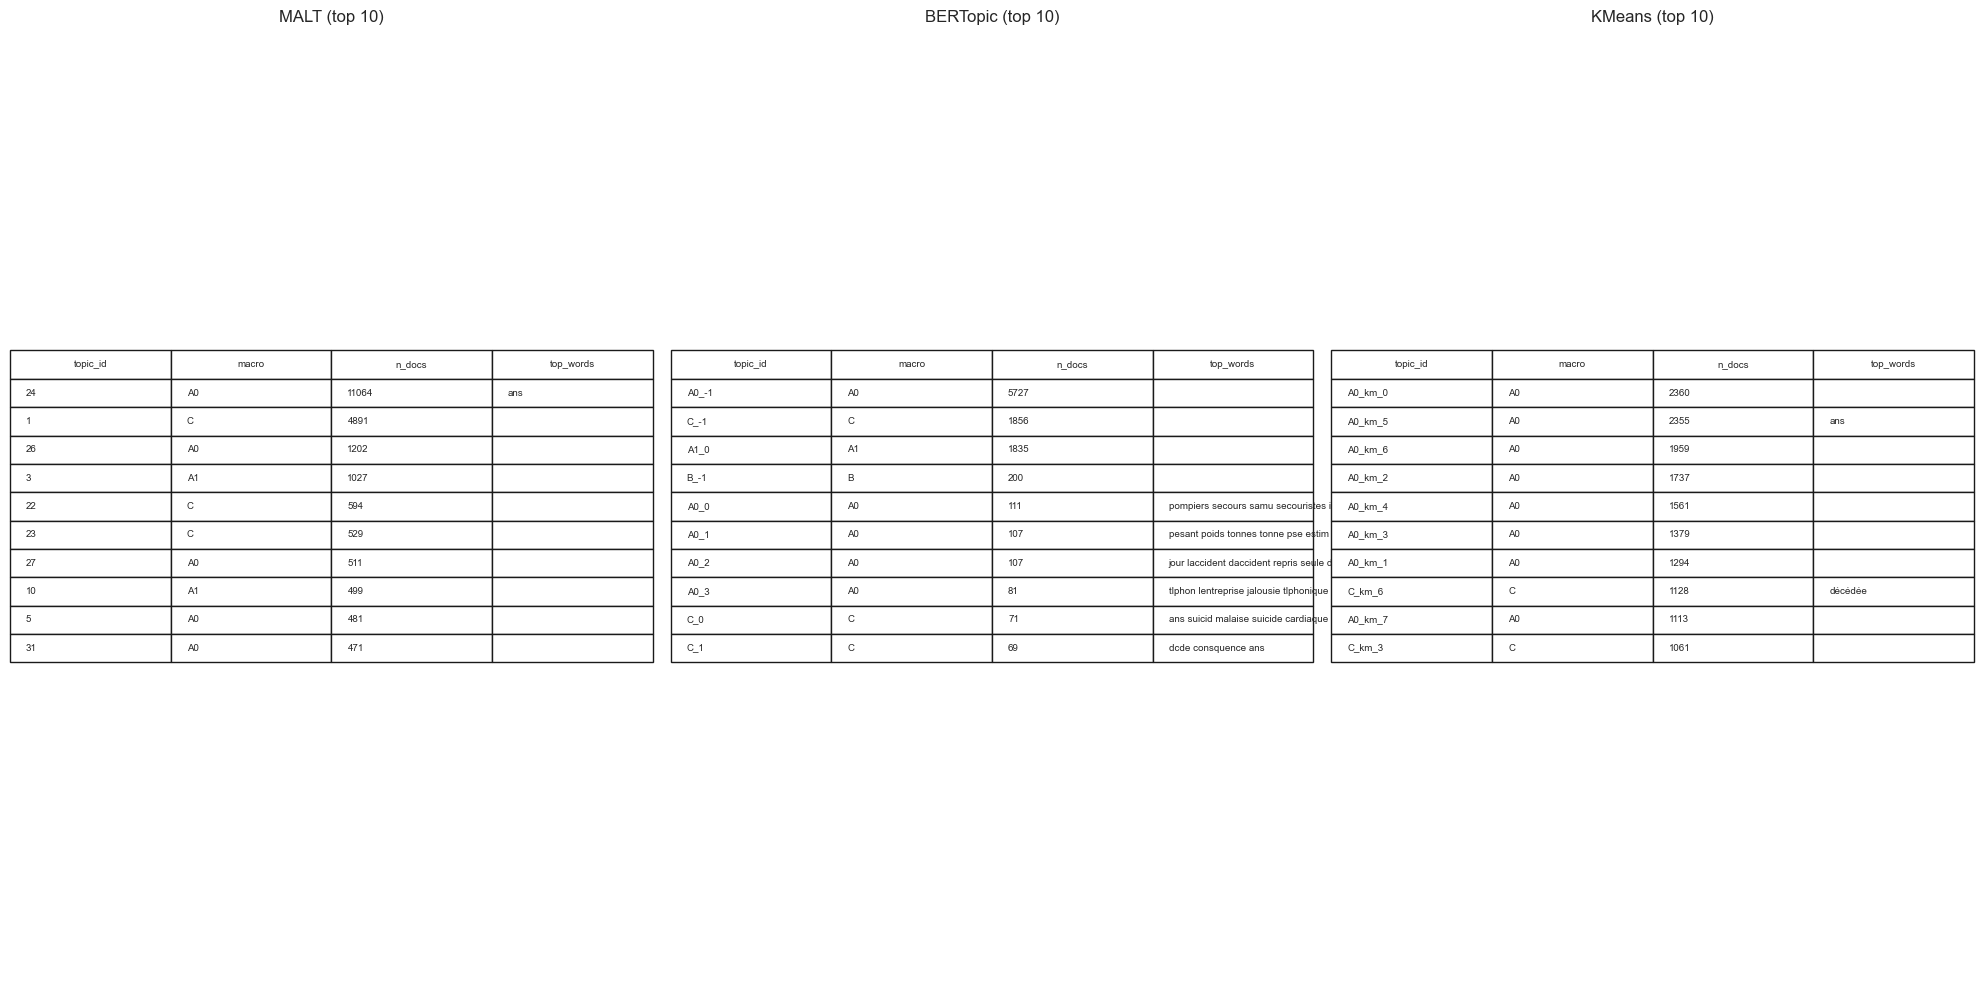

In [19]:
topics_long = pd.concat([malt_topics_df, bertopic_topics_df, kmeans_topics_df], ignore_index=True)
save_all_comparison_figures(comparison_metrics_df, topics_long, fig_dir)
print("Figures enregistrées dans", fig_dir)

# Tableau visuel (top 10 par méthode)
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for ax, (title, df) in zip(
    axes,
    [
        ("MALT (top 10)", malt_topics_df),
        ("BERTopic (top 10)", bertopic_topics_df),
        ("KMeans (top 10)", kmeans_topics_df),
    ],
):
    ax.axis("off")
    ax.set_title(title, fontsize=12, pad=12)
    sub = df.sort_values("n_docs", ascending=False).head(10)
    if sub.empty:
        continue
    tbl = ax.table(
        cellText=sub[["topic_id", "macro", "n_docs", "top_words"]].values,
        colLabels=["topic_id", "macro", "n_docs", "top_words"],
        loc="center",
        cellLoc="left",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    tbl.scale(1.0, 1.4)
plt.tight_layout()
plt.savefig(fig_dir / "top10_topics_table_by_method.png", dpi=150, bbox_inches="tight")
plt.show()


## 11 — Exemples de topics


In [20]:
from typing import Optional

def display_topic_examples(
    topics_df: pd.DataFrame,
    method_name: Optional[str] = None,
    macro: Optional[str] = None,
    n_topics: int = 5,
):
    df = topics_df.copy()
    if method_name:
        df = df[df["method"].astype(str).str.contains(method_name, case=False, na=False)]
    if macro:
        df = df[df["macro"].astype(str) == macro]
    df = df.sort_values("n_docs", ascending=False).head(n_topics)
    for _, r in df.iterrows():
        print("\n---")
        print("méthode:", r.get("method"))
        print("topic_id:", r.get("topic_id"), "| macro:", r.get("macro"), "| n_docs:", r.get("n_docs"))
        print("top_words:", r.get("top_words"))
        print("phrases:\n", str(r.get("top_sentences", "")).replace(" || ", "\n"))

display_topic_examples(malt_topics_df, "MALT", None, 5)
display_topic_examples(bertopic_topics_df, "BERTopic", None, 5)
display_topic_examples(kmeans_topics_df, "KMeans", None, 5)
for macro in ["A0", "A1", "B", "C"]:
    print("\n===== Macro", macro, "=====")
    display_topic_examples(malt_topics_df, "MALT", macro, 4)
    display_topic_examples(bertopic_topics_df, "BERTopic", macro, 4)
    display_topic_examples(kmeans_topics_df, "KMeans", macro, 4)



---
méthode: MALT adapted + c-TF-IDF
topic_id: 24 | macro: A0 | n_docs: 11064
top_words: ans
phrases:
 Un salarié de 25 ans, affecté au poste de carrossier poids lourds depuis un peu plus de trois mois, terminait une seconde période d'essai.
Un monteur mécanicien de 24 ans termine sa journée de travail (6 - 13 heures) sur la ligne de montage des essieux sur laquelle il occupe le premier poste de travail.
Dans le cadre de sa polyvalence, un opérateur à pied de 47 ans traverse l'atelier de contrôle des produits finis (barre d'acier d'environ 3 mètres de longueur) pour effectuer une opération de maintenance et de nettoyage courant sur l'installation d'une des travées.
Le chef d'équipe demande à un mécanicien poids lourd de 57 ans de le sortir de l'atelier par le portail.
La victime est aide-monteur de 23 ans, dans une entreprise de fabrication, montage, entretien d'ascenseurs.
Le salarié, âgé de 35 ans, peintre en carrosserie, devait effectuer des travaux en cabine sur une benne de camio

## 12 — Tableau qualitatif aligné par macro


In [21]:
qual_df = build_topics_by_macro_qualitative(malt_topics_df, bertopic_topics_df, kmeans_topics_df)
qual_df.to_csv(tables_dir / "topics_by_macro_qualitative.csv", index=False)
display(qual_df.head(20))


,macro,method,topic_id,n_docs,top_words,top_sentence_1,top_sentence_2,top_sentence_3
0,A0,MALT adapted + c-TF-IDF,24,11064,ans,"Un salarié de 25 ans, affecté au poste de carr...",Un monteur mécanicien de 24 ans termine sa jou...,"Dans le cadre de sa polyvalence, un opérateur ..."
1,A0,MALT adapted + c-TF-IDF,26,1202,,Les salariés sont « libres » et ils travailler...,Le chaudronnier refuse.,"Or sur la nouvelle installation, il n'y a pas ..."
2,A0,MALT adapted + c-TF-IDF,27,511,,Le poste de travail et le mode opératoire ne p...,Lurgence de la réparation était présente mais...,On lui indique que la pelle se situe dans un b...
3,A0,MALT adapted + c-TF-IDF,5,481,,Il s'aperçoit qu'une gouttière est remplie de ...,Le levage a ensuite repris.,Elle s'est dégagée seule en utilisant la pédal...
4,A0,MALT adapted + c-TF-IDF,31,471,,Plusieurs font écho à une situation personnell...,L'un des d'eux a tiré trois balles de pistolet...,Les pompiers étaient encore là et emmenaient s...
5,A0,MALT adapted + c-TF-IDF,28,25,machine,Les collègues ne peuvent dégager la victime qu...,Elle crie et l'installation est arrêtée par un...,Il aurait donc retiré une première cale en boi...
6,A0,MALT adapted + c-TF-IDF,7,16,,La victime avait reçu une formation par le che...,Suite aux deux dernières opérations effectuées...,Aucune information entre le moment où elle est...
7,A0,BERTopic intra-macro via p0,A0_-1,5727,,"Un responsable bureau détude et marketing, âg...",Le monte-charge est piloté à distance par un c...,"La cause de l'accident n'est pas déterminée, l..."
8,A0,BERTopic intra-macro via p0,A0_0,111,pompiers secours samu secouristes intervenus s...,Les pompiers rejoignent les SST et prennent en...,"Les pompiers sont arrivés environ 15 mn après,...",Les pompiers interviennent immédiatement sur l...
9,A0,BERTopic intra-macro via p0,A0_1,107,pesant poids tonnes tonne pse estim kilos environ,La hauteur de la charge est d'environ 360 mm p...,Le poids global de ce paquet est estimé à envi...,Le poids global de ce paquet est estimé à envi...


## 13 — Qualité par macro (p0 sur les documents)


In [22]:
macro_rows = []
for label, tdf in methods:
    macro_rows.append(macro_level_metrics(tdf, docs, MACRO_P0_COL, meta, label, stopwords_domain, N_TOP_WORDS, MIN_TOPIC_SIZE))
macro_topic_quality = pd.concat(macro_rows, ignore_index=True)
macro_topic_quality.to_csv(tables_dir / "macro_topic_quality.csv", index=False)
macro_topic_quality.to_latex(tables_dir / "macro_topic_quality.tex", index=False, float_format="%.3f")
display(macro_topic_quality.round(3))


,method,macro,n_docs,n_topics,coverage_macro,mean_topic_size,cv_macro,npmi_macro,diversity_macro
0,MALT adapted + c-TF-IDF,A0,13758,7,1.001,1967.143,NaN,NaN,0.029
1,MALT adapted + c-TF-IDF,A1,1846,3,0.892,549.000,NaN,NaN,0.000
2,MALT adapted + c-TF-IDF,B,832,3,1.016,281.667,NaN,NaN,0.000
3,MALT adapted + c-TF-IDF,C,6051,5,1.029,1245.000,NaN,NaN,0.020
4,BERTopic intra-macro via p0,A0,13758,546,0.584,25.534,0.304,-0.189,0.836
5,BERTopic intra-macro via p0,A1,1846,2,1.000,1835.000,NaN,NaN,0.000
6,BERTopic intra-macro via p0,B,832,44,0.760,22.562,0.454,-0.228,0.656
7,BERTopic intra-macro via p0,C,6051,280,0.693,23.761,0.382,-0.141,0.689
8,KMeans intra-macro + c-TF-IDF,A0,13758,8,1.000,1719.750,NaN,NaN,0.012
9,KMeans intra-macro + c-TF-IDF,A1,1846,8,1.000,230.750,NaN,NaN,0.012


## 14 — Rapport Markdown automatique


In [23]:
write_topic_comparison_report_md(
    Path(OUTPUT_DIR) / "topic_comparison_report.md",
    comparison_metrics_df,
    str(STOPWORDS_PATH),
    n_valid,
    str(fig_dir),
)
print("Rapport :", Path(OUTPUT_DIR) / "topic_comparison_report.md")


Rapport : C:\Users\aho\Documents\analysis factor project\SCGM\SCGM\outputs\topic_comparison\topic_comparison_report.md


## 15 — Export LaTeX


In [24]:
# Déjà écrit : topic_quality_comparison.tex, macro_topic_quality.tex
print("LaTeX :", tables_dir / "topic_quality_comparison.tex")


LaTeX : C:\Users\aho\Documents\analysis factor project\SCGM\SCGM\outputs\topic_comparison\tables\topic_quality_comparison.tex


## 16 — Notes

- Ne pas utiliser `pred_label` comme référence principale.
- Baselines intra-macro : **uniquement** `p0_macro_name`.
- Dépendances manquantes : `pip install bertopic` ou `pip install gensim` selon les messages d’erreur.
